In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = '''
SELECT 
    uid,
    DATE(timestamp) as timestamp,
    numTrials
FROM 
    checker
WHERE 
    uid LIKE 'user%' AND status == 'ready' AND labname IN ('project1')
'''

df = pd.read_sql_query(query, conn)

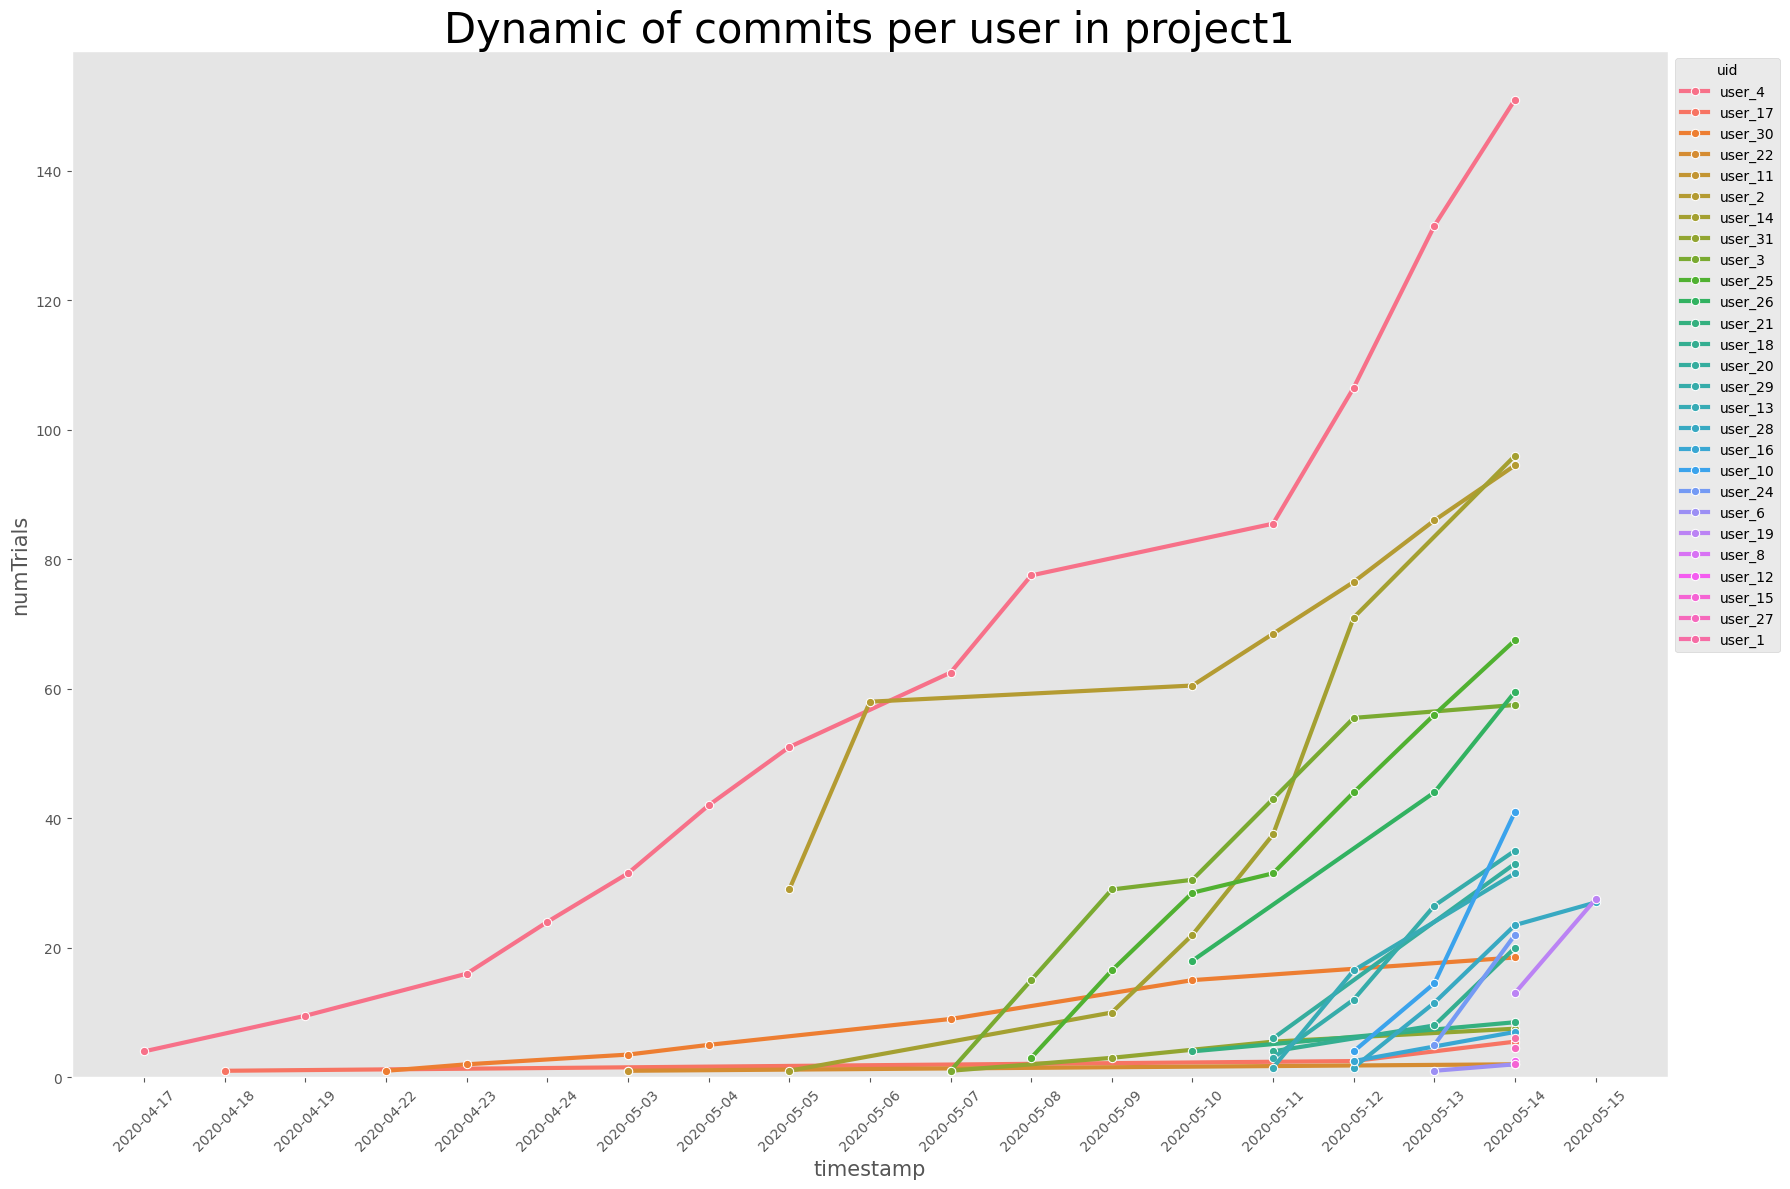

In [4]:
plt.style.use('ggplot')
plt.figure(figsize=(18, 12))
sns.lineplot(data=df, x='timestamp', y='numTrials', hue='uid', marker='o', dashes=False, errorbar=None, linewidth=3)
plt.title('Dynamic of commits per user in project1', fontsize=30)
plt.xlabel('timestamp', fontsize=15)
plt.ylabel('numTrials', fontsize=15)
plt.xticks(rotation=45)
plt.ylim(bottom=0)
plt.grid()
plt.legend(title='uid', loc='upper left', bbox_to_anchor=(1, 1))
# Отображение графика
plt.tight_layout()
plt.show()

In [5]:
conn.close()